# Homework 01: Binary Classification with Neural Networks

## Due: Sunday January 25 @ 11:59 (with 2-hour grace period) and worth 85 points

In this assignment, you'll build your first deep learning models using **Keras**, a high-level deep learning framework built on TensorFlow.

We’ll solve a binary classification task, using the Wisconsin Breast Cancer dataset. 

You’ll start by training a simple baseline model, and then explore a series of alternate network designs.  For each model, you’ll:

- Track training loss and accuracy over epochs
- Report final test set performance (loss and accuracy)

The goal is to begin developing an intuition for how network design choices influence performance—and to get comfortable with the end-to-end modeling workflow in Keras.


There are 12 graded problems, each worth 7 points, and you get 1 point free. 


In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # 0=all, 1=filter INFO, 2=filter INFO+WARNING, 3=errors only

In [2]:
%pip install numpy pandas matplotlib seaborn scikit-learn tensorflow

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Useful Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Sequential

random_seed = 42

In [4]:
# Utility function: Plotting Training Loss (x-entropy) and Accuracy
# We'll replace this with a different function train_and_test when we develop more
# training techniques.

# Takes the history object returned by fit

def plot_history(history):
    n_epochs = len(history.history['accuracy'])
    epochs = range(1, n_epochs + 1)

    plt.figure(figsize=(7, 8))

    plt.subplot(2, 1, 1)
    plt.plot(epochs, history.history['loss'], label='Training Loss (Xent)', color='tab:red')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.grid(True)
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(epochs, history.history['accuracy'], label='Training Accuracy', color='tab:blue')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1.05)
    plt.title('Training Accuracy')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

    final_loss = history.history['loss'][-1]
    final_acc = history.history['accuracy'][-1]
    print(f'Final Training Loss:     {final_loss:.4f}')
    print(f'Final Training Accuracy: {final_acc:.4f}')


## Prelude: Load and Explore the Wisconsin Breast Cancer Dataset

You should **always** perform EDA when working with a new dataset. We've seen this one before, but its always worth becoming familiar with the data before building a model!

In [5]:
# Load dataset with as DataFrame for EDA
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer(as_frame=True)

df = data.frame  # Convenient alias for combined data+target

In [6]:
# Uncomment and look at this

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

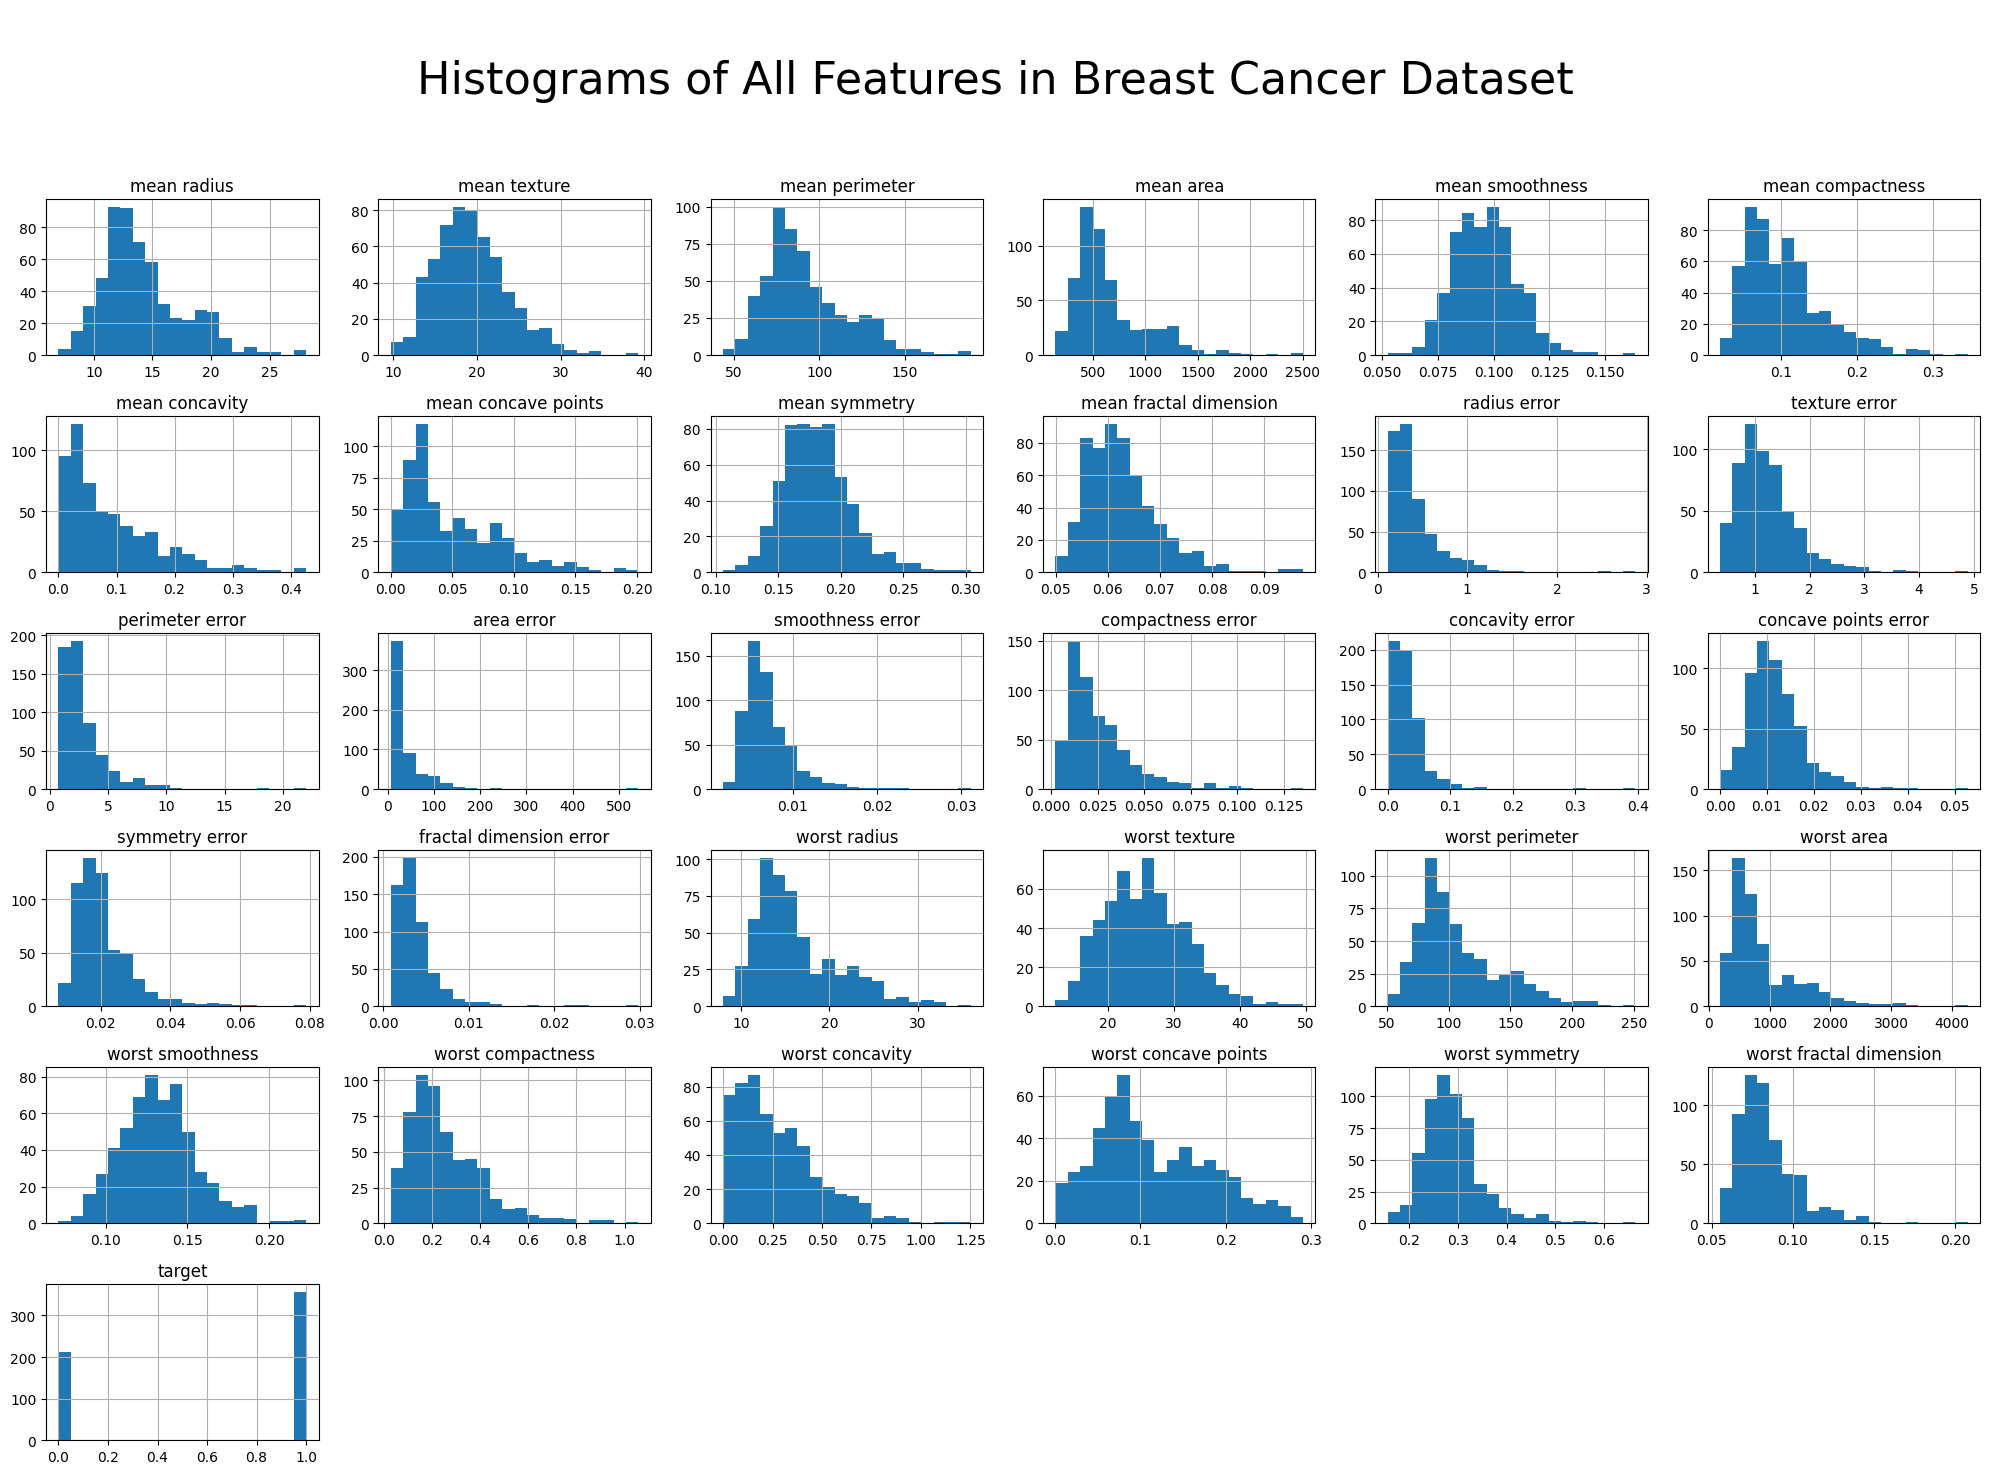

In [7]:
# Uncomment and look at this

fig = df.hist(bins=20, figsize=(20, 15), layout=(6, 6))
plt.suptitle("\nHistograms of All Features in Breast Cancer Dataset", fontsize=32)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for the title
plt.show()

## Problem One: Dealing with unbalanced target variables and establishing a baseline model

### Part A: Compute the imbalance of the target

Neural networks work best with standardized datasets; for classification tasks, it is also important
to account for an unbalanced target. Let's create our `X,y` data structure and look at the target more closely. 

1. **Convert the data to NumPy arrays:** Extract the feature matrix `X` and the target vector `y` from the DataFrame, and
convert them to NumPy arrays. Print the shapes of `X` and `y` to confirm the conversion was successful.  

2. **Check for class imbalance:**
   Use `Counter` (or another appropriate method) to print the frequency of each class label in the target array `y`. This will help you understand how balanced (or imbalanced) the classes are.

3. **Compute the proportion of class 1:**
   Calculate what percentage of the samples belong to class label `1` and provide your answer in the graded question. 



In [8]:
# A.1
# Convert the feature matrix (X) and target vector (y) from pandas -> NumPy.
# This is the standard “model-ready” format most ML libraries expect.

X = df.drop(columns="target").to_numpy()
y = df["target"].to_numpy()

# Validation: shapes should match the conceptual structure:
# - X: (n_samples, n_features)
# - y: (n_samples,)
print("X shape:", X.shape)
print("y shape:", y.shape)

# Quick sanity check: number of rows in X should equal length of y
assert X.shape[0] == len(y), "Sanity check failed: X rows != y length"


X shape: (569, 30)
y shape: (569,)


,class_label,count,proportion
0,0,212,0.372583
1,1,357,0.627417


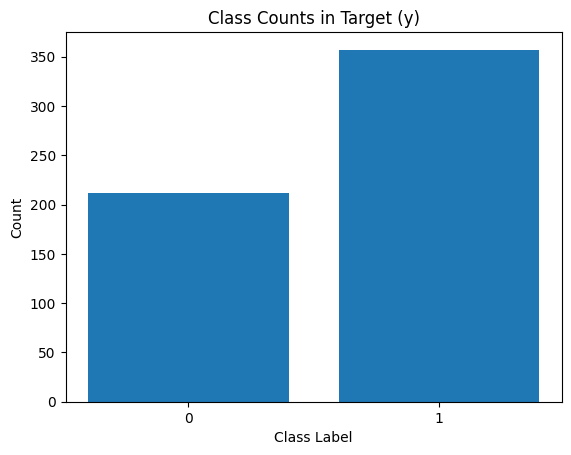

In [9]:
# A.2

# Count how many examples we have of each class label in y.
# This makes imbalance explicit (instead of guessing).

from collections import Counter

class_counts = Counter(y)

# Build a small, readable validation table
counts_df = (
    pd.DataFrame({"class_label": list(class_counts.keys()),
                  "count": list(class_counts.values())})
      .sort_values("class_label")
      .reset_index(drop=True)
)

# Add proportions for extra clarity
counts_df["proportion"] = counts_df["count"] / counts_df["count"].sum()

display(counts_df)

# Visual validation: bar chart of class counts
plt.figure()
plt.bar(counts_df["class_label"].astype(str), counts_df["count"])
plt.title("Class Counts in Target (y)")
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.show()


In [10]:
# A.3

# Set a1a to the percentage (a float between 0 and 1) of 1's in the target
# Use an expression, not constants derived from inspecting the data


a1a = np.mean(y == 1)

# Validation: compare to the proportion column from our table
prop_from_table = counts_df.loc[counts_df["class_label"] == 1, "proportion"].iloc[0]

print("a1a (computed with np.mean):", a1a)
print("Proportion from table:", prop_from_table)

# These should match (allowing for floating point formatting)
assert np.isclose(a1a, prop_from_table), "Validation failed: proportions do not match"

a1a (computed with np.mean): 0.6274165202108963
Proportion from table: 0.6274165202108963


In [11]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1a = {a1a:.4f}')                     

a1a = 0.6274


### Part B: Perform a stratified test/train split

In classification problems with imbalanced datasets, it's important to address the class imbalance so that the model doesn't become biased toward the majority class. There are two common strategies:

* **Resampling** the dataset to balance the classes (by oversampling the minority class or undersampling the majority class).
* **Adjusting the loss function** so that errors on minority classes have more influence during training.

In this problem, you'll explore the second approach—using class weights to influence how the model learns.

This strategy involves two key steps:

1. **Preserve class proportions in the train/test split**
   Use the  parameter `stratify=y`in `train_test_split` to ensure that both the training and testing sets maintain the same class distribution as in the original target.

2. **Apply class weighting during training**
   Use the `class_weight` parameter in the `fit` function to assign different weights to each class when computing the loss. This helps ensure that the model pays appropriate attention to both common and rare classes.


**We'll do the first step now, perform standardization, and then do the second step in Part C.** 

In [12]:
# Perform train-test split, keeping both stratified, use random_state = random_seed and test_size = 0.2

# Stratification ensures the class proportions in y are preserved in both splits.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=random_seed,
    stratify=y
)

# Basic validation: sizes should add up correctly
print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 455
Test size: 114


**(Digression:** We must perform standardization **after** the test/train split, or else we're letting
information about the mean and standard deviation of the test set influence training--a classic case of *data leakage*.
**)**

In [13]:
# As usual, standardize the features

# IMPORTANT: fit the scaler on training data only to avoid data leakage.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Validation: scaled training features should have ~0 mean and ~1 std
print("Training mean (first 5 features):", X_train_scaled.mean(axis=0)[:5])
print("Training std  (first 5 features):", X_train_scaled.std(axis=0)[:5])



Training mean (first 5 features): [-4.31742554e-15  2.24606658e-15 -7.38359313e-16  1.71779562e-16
  5.22695440e-15]
Training std  (first 5 features): [1. 1. 1. 1. 1.]


,Dataset,Proportion of Class 1
0,Original,0.627417
1,Train,0.626374
2,Test,0.631579


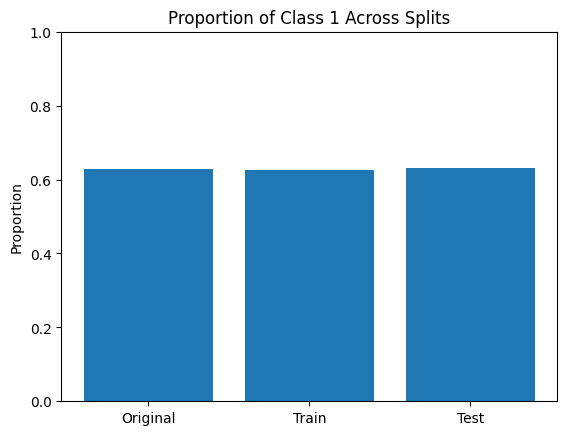

In [14]:
# Validate stratification by comparing class proportions
# across original data, training set, and test set.

def class_proportion(y, label):
    return (y == label).mean()

proportion_df = pd.DataFrame({
    "Dataset": ["Original", "Train", "Test"],
    "Proportion of Class 1": [
        class_proportion(y, 1),
        class_proportion(y_train, 1),
        class_proportion(y_test, 1)
    ]
})

display(proportion_df)

# Visual comparison
plt.figure()
plt.bar(proportion_df["Dataset"], proportion_df["Proportion of Class 1"])
plt.title("Proportion of Class 1 Across Splits")
plt.ylabel("Proportion")
plt.ylim(0, 1)
plt.show()

Let's see if the stratification worked! Assign `a1b` to the percentage of 1's in `y_train` (and convince yourself that if it is approximately correct, then so must be `y_test`). 

In [15]:
# Set a1b to the percentage (a float between 0 and 1) of 1's in the target
# Use an expression, not constants derived from inspecting the data

a1b = np.mean(y_test == 1)

In [16]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1b = {a1b:.4f}')  

a1b = 0.6316


## Part C: Train a baseline model with class weighting

Now we'll build a baseline model with class weighting during training. 

To compute the weight for class $i$, use the following formula:

$$
\text{weight}_i = \frac{n}{k \cdot n_i},
$$

where:

* $n$ is the total number of samples,
* $n_i$ is the number of samples in class $i$,
* $k$ is the total number of classes.

This formula scales the loss so that each class contributes approximately equally during training—without changing the number of training samples.

To apply class weighting during training, we use the parameter `class_weight=weights` in the `fit` function, where `weights` is a dictionary 

    { 0 : weight_0, 1 : weight_1 }

as specified in the formula above. 

**Note**: As an alternative, you can also use `sklearn.utils.class_weight` to do the calculation. 

**TODO: Complete the template to**

-  Build a network consisting of a single logistic regression classifier (done for you!)
-  Compile it using the same parameters as shown in the coding video, except we will use the `Adam` optimizer:
>          optimizer='adam'
-  Train it for **100** epochs, calculating the class weights explicitly as shown or using `sklearn.utils.class_weight` (look up the docs!)
-  Display the training loss and accuracy curves using `plot_history`
-  Complete the graded question 

Class weights: {np.int64(1): 0.7982456140350878, np.int64(0): 1.338235294117647}


2026-01-27 06:31:44.596019: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

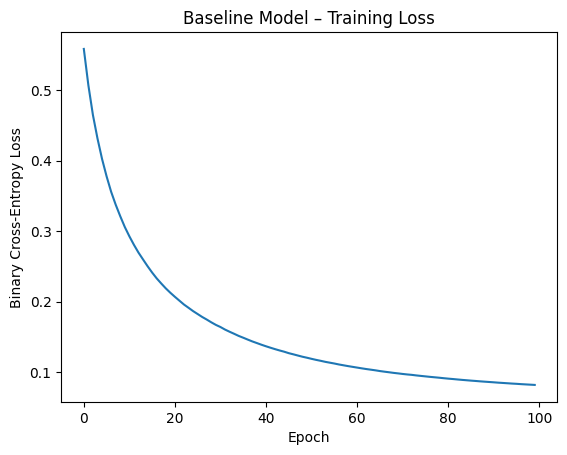

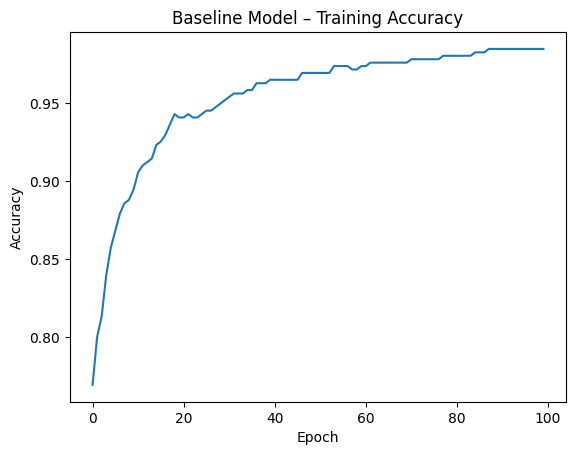

In [17]:
# Try a baseline model consisting of a single logistic regression classifier.
# This is very similar to sklearn's LogisticRegression model.

n_epochs = 100

# -------------------------------------------------------------------
# Step 1: Compute class weights explicitly (as required by the prompt)
# -------------------------------------------------------------------
# Class weights rebalance the loss so minority-class errors matter more
# during optimization, without resampling the data.

from collections import Counter

class_counts = Counter(y_train)

n = len(y_train)          # total number of training samples
k = len(class_counts)     # number of classes (binary -> 2)

class_weights = {
    cls: n / (k * count)
    for cls, count in class_counts.items()
}

# Optional validation print (safe for autograder)
print("Class weights:", class_weights)

# -------------------------------------------------------------------
# Step 2: Define the baseline logistic regression model
# -------------------------------------------------------------------
# One sigmoid neuron = logistic regression implemented in Keras

model_baseline = keras.Sequential(
    [
        keras.layers.Input(shape=(X_train_scaled.shape[1],)),  # Explicit input layer
        keras.layers.Dense(1, activation="sigmoid")
    ]
)

model_baseline.summary()

# -------------------------------------------------------------------
# Step 3: Compile the model
# -------------------------------------------------------------------
# Binary cross-entropy is the correct loss for probabilistic binary classification

model_baseline.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# -------------------------------------------------------------------
# Step 4: Train the model with class weighting
# -------------------------------------------------------------------
# Class weights influence the loss during training (not the data itself)

history_baseline = model_baseline.fit(
    X_train_scaled,
    y_train,
    epochs=n_epochs,
    batch_size=32,
    class_weight=class_weights,
    verbose=0
)

# -------------------------------------------------------------------
# Step 5: Display training loss and accuracy curves (required)
# -------------------------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt

history_df = pd.DataFrame(history_baseline.history)

plt.figure()
plt.plot(history_df["loss"])
plt.title("Baseline Model – Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.show()

plt.figure()
plt.plot(history_df["accuracy"])
plt.title("Baseline Model – Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

In [18]:
# Set a1c to the final training accuracy (at epoch 100)
# You MUST use an expression here, not a constant from inspecting the results

a1c = history_baseline.history["accuracy"][-1]

In [19]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1c = {a1c:.4f}')  

a1c = 0.9846


### Part D: Testing

- Calculate the testing loss and accuracy and answer the graded question.
- Print out both with appropriate labels
- Answer the graded question

In [20]:
# Your code here
# Evaluate the baseline model on the test set.
# This measures how well the trained model generalizes to unseen data.

test_loss, test_accuracy = model_baseline.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


Test Loss: 0.1053
Test Accuracy: 0.9649


In [21]:
# Set a1d to the final testing accuracy
# Use the appropriate variable; do not insert a constant from inspection of the results

a1d = test_accuracy

In [22]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1d = {a1d:.4f}') 

a1d = 0.9649


## Problem Two: Explore alternate network designs

For the remaining problems, you will experiment with several different network designs.

For Problem Two, redo the work you did in Parts C and D of Problem One, but with a network with a single hidden layer of 16 neurons, using the sigmoid activation function, which
will have the following summary chart (the layer name may be different than shown here):

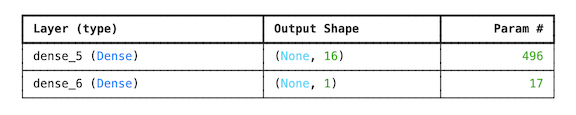


Then answer the graded questions.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

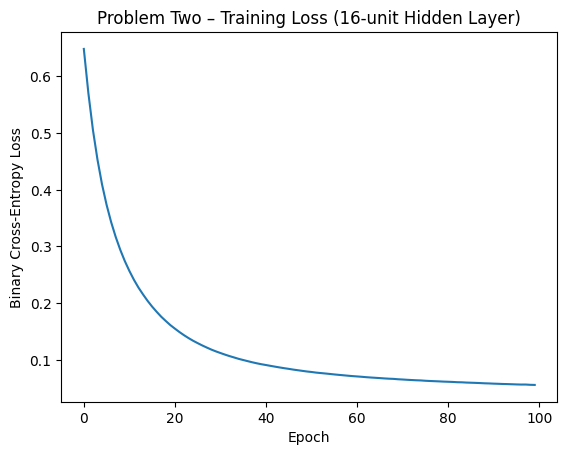

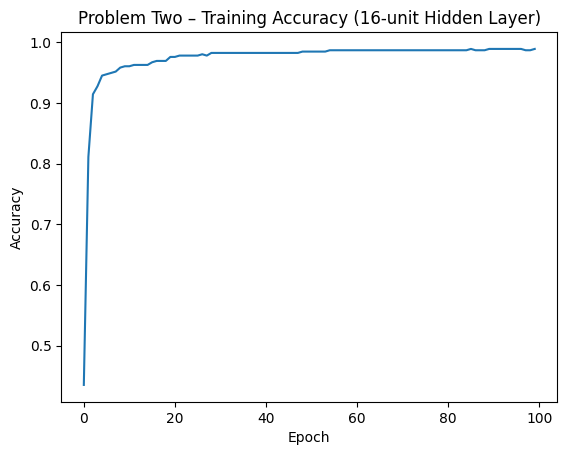

In [23]:
# Your code here, add additional cells if you wish
# ------------------------------------------------------------
# Problem Two: Alternate network design
# One hidden layer with 16 neurons (sigmoid activation)
# ------------------------------------------------------------
# This repeats Parts C and D from Problem One, changing only
# the network architecture. Everything else stays the same.
#
# Conceptually:
# - Baseline = logistic regression
# - This model adds capacity via a hidden layer
# - We test whether extra capacity improves learning
# ------------------------------------------------------------

n_epochs = 100

# ------------------------------------------------------------
# Step 1: Define the model
# ------------------------------------------------------------
# Architecture:
# Input -> Dense(16, sigmoid) -> Dense(1, sigmoid)

model_p2 = keras.Sequential(
    [
        keras.layers.Input(shape=(X_train_scaled.shape[1],)),
        keras.layers.Dense(16, activation="sigmoid"),
        keras.layers.Dense(1, activation="sigmoid")
    ]
)

model_p2.summary()

# ------------------------------------------------------------
# Step 2: Compile the model
# ------------------------------------------------------------
# Same optimizer and loss as the baseline to ensure
# a fair comparison between models.

model_p2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# ------------------------------------------------------------
# Step 3: Train the model with class weighting
# ------------------------------------------------------------
# Class weights are reused to ensure the minority class
# continues to influence optimization appropriately.

history_p2 = model_p2.fit(
    X_train_scaled,
    y_train,
    epochs=n_epochs,
    batch_size=32,
    class_weight=class_weights,
    verbose=0
)

# ------------------------------------------------------------
# Step 4: Visualize training loss and accuracy
# ------------------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt

history_p2_df = pd.DataFrame(history_p2.history)

# Training loss
plt.figure()
plt.plot(history_p2_df["loss"])
plt.title("Problem Two – Training Loss (16-unit Hidden Layer)")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.show()

# Training accuracy
plt.figure()
plt.plot(history_p2_df["accuracy"])
plt.title("Problem Two – Training Accuracy (16-unit Hidden Layer)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

# ------------------------------------------------------------
# Step 5: Set the graded answer (final training accuracy)
# ------------------------------------------------------------
# Use an expression, not a constant from inspecting results.

a2a = history_p2.history["accuracy"][-1]


In [24]:
# Set a2a to the final training accuracy
# Use the appropriate variable or expression; do not insert a constant from inspection of the results

a2a = history_p2.history["accuracy"][-1]            # Replace 0.0 with your answer

In [25]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2a = {a2a:.4f}') 

a2a = 0.9890


In [26]:
# Set a2b to the final testing accuracy
# Use the appropriate variable; do not insert a constant from inspection of the results
# ------------------------------------------------------------
# Problem Two – Testing
# Evaluate the trained 16-unit hidden layer model on the test set
# ------------------------------------------------------------

test_loss_p2, test_accuracy_p2 = model_p2.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print(f"Problem Two Test Loss: {test_loss_p2:.4f}")
print(f"Problem Two Test Accuracy: {test_accuracy_p2:.4f}")


a2b = test_accuracy_p2

Problem Two Test Loss: 0.1003
Problem Two Test Accuracy: 0.9474


In [27]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2b = {a2b:.4f}') 

a2b = 0.9474


## Problem Three: Explore alternate network designs


For Problem Three, redo the work you did in Parts C and D of Problem One, but with a network with a  hidden layer of 64 neurons, 
using the sigmoid activation function, which
will have the following summary chart:

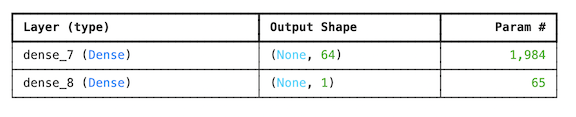


Then answer the graded questions.

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,049 (8.00 KB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 0 (0.00 B)

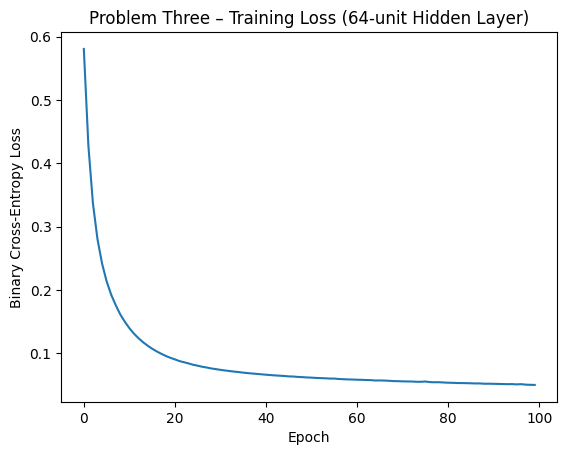

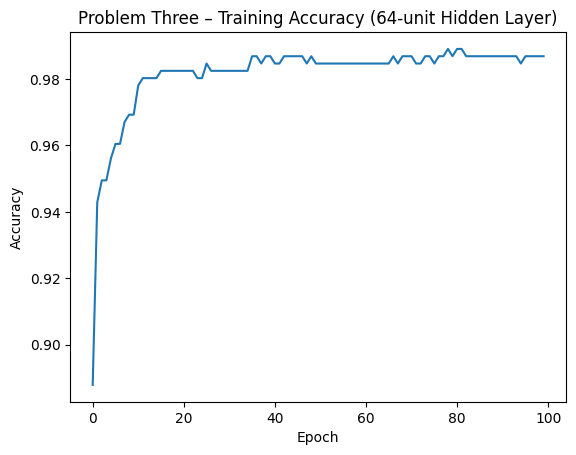

In [28]:
# Your code here, add additional cells if you wish
# ------------------------------------------------------------
# Problem Three: Training
# Network with one hidden layer of 64 neurons (sigmoid)
# ------------------------------------------------------------

n_epochs = 100

# Step 1: Define the model
model_p3 = keras.Sequential(
    [
        keras.layers.Input(shape=(X_train_scaled.shape[1],)),
        keras.layers.Dense(64, activation="sigmoid"),
        keras.layers.Dense(1, activation="sigmoid")
    ]
)

model_p3.summary()

# Step 2: Compile the model
# Same optimizer and loss as prior problems for fair comparison
model_p3.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Step 3: Train the model with class weighting
history_p3 = model_p3.fit(
    X_train_scaled,
    y_train,
    epochs=n_epochs,
    batch_size=32,
    class_weight=class_weights,
    verbose=0
)

# Step 4: Visualize training curves

history_p3_df = pd.DataFrame(history_p3.history)

plt.figure()
plt.plot(history_p3_df["loss"])
plt.title("Problem Three – Training Loss (64-unit Hidden Layer)")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.show()

plt.figure()
plt.plot(history_p3_df["accuracy"])
plt.title("Problem Three – Training Accuracy (64-unit Hidden Layer)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()


In [29]:
# Set a3a to the final training accuracy
# Use the appropriate variable or expression; do not insert a constant from inspection of the results

a3a = history_p3.history["accuracy"][-1]

In [30]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3a = {a3a:.4f}') 

a3a = 0.9868


In [31]:
# Set a3b to the final testing accuracy
# Use the appropriate variable; do not insert a constant from inspection of the results

# ------------------------------------------------------------
# Problem Three – Testing
# Evaluate generalization performance on unseen test data
# ------------------------------------------------------------

test_loss_p3, test_accuracy_p3 = model_p3.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print(f"Problem Three Test Loss: {test_loss_p3:.4f}")
print(f"Problem Three Test Accuracy: {test_accuracy_p3:.4f}")

a3b = test_accuracy_p3

Problem Three Test Loss: 0.0930
Problem Three Test Accuracy: 0.9474


In [32]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3b = {a3b:.4f}') 

a3b = 0.9474


## Problem Four: Explore alternate network designs


For Problem Four, redo the work you did in Parts C and D of Problem One, but with a network with  a hidden layer of 256 neurons, using the sigmoid activation function, which
will have the following summary chart:

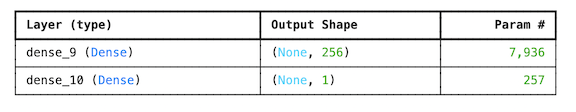


Then answer the graded questions.

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 256)            │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,193 (32.00 KB)

 Trainable params: 8,193 (32.00 KB)

 Non-trainable params: 0 (0.00 B)

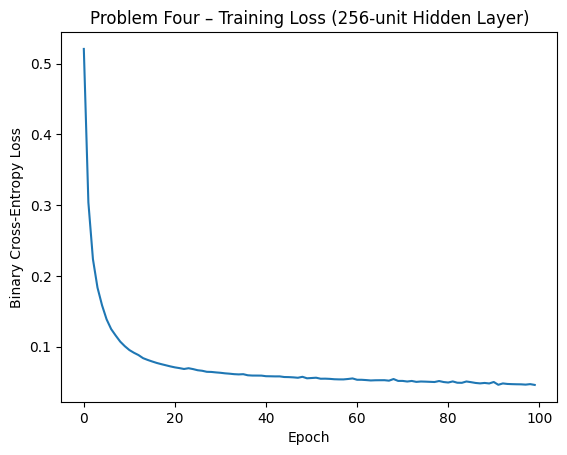

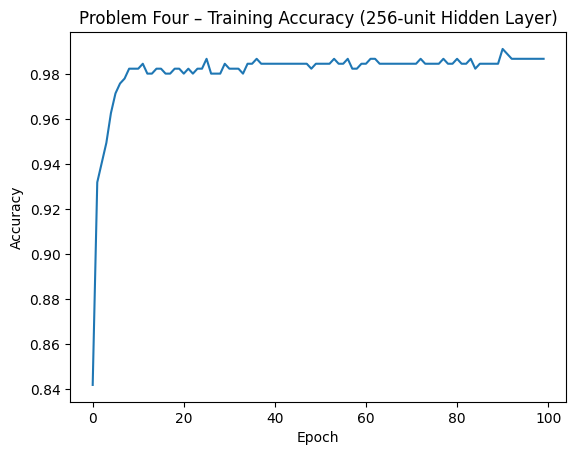

In [33]:
# Your code here, add additional cells if you wish
# ------------------------------------------------------------
# Problem Four: Training
# One hidden layer with 256 neurons (sigmoid activation)
# ------------------------------------------------------------
# This model has significantly higher capacity.
# The goal is to observe whether additional capacity:
# - improves performance
# - or leads to overfitting / diminishing returns
# ------------------------------------------------------------

n_epochs = 100

# Step 1: Define the model
model_p4 = keras.Sequential(
    [
        keras.layers.Input(shape=(X_train_scaled.shape[1],)),
        keras.layers.Dense(256, activation="sigmoid"),
        keras.layers.Dense(1, activation="sigmoid")
    ]
)

model_p4.summary()

# Step 2: Compile the model
model_p4.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Step 3: Train the model with class weighting
history_p4 = model_p4.fit(
    X_train_scaled,
    y_train,
    epochs=n_epochs,
    batch_size=32,
    class_weight=class_weights,
    verbose=0
)

# Step 4: Visualize training curves

history_p4_df = pd.DataFrame(history_p4.history)

plt.figure()
plt.plot(history_p4_df["loss"])
plt.title("Problem Four – Training Loss (256-unit Hidden Layer)")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.show()

plt.figure()
plt.plot(history_p4_df["accuracy"])
plt.title("Problem Four – Training Accuracy (256-unit Hidden Layer)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()


In [34]:
# Set a4a to the final training accuracy
# Use the appropriate variable or expression; do not insert a constant from inspection of the results

a4a = history_p4.history["accuracy"][-1]

In [35]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4a = {a4a:.4f}') 

a4a = 0.9868


In [43]:
# Set a4b to the final testing accuracy
# Use the appropriate variable; do not insert a constant from inspection of the results

# ------------------------------------------------------------
# Problem Four – Testing
# Evaluate the 256-unit hidden layer model on the test set
# ------------------------------------------------------------

test_loss_p4, test_accuracy_p4 = model_p4.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print(f"Problem Four Test Loss: {test_loss_p4:.4f}")
print(f"Problem Four Test Accuracy: {test_accuracy_p4:.4f}")

a4b = test_accuracy_p4a4b = test_accuracy_p4

Problem Four Test Loss: 0.0875
Problem Four Test Accuracy: 0.9474


In [44]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4b = {a4b:.4f}') 

a4b = 0.9474


## Problem Five: Explore alternate network designs


For Problem Five, redo the work you did in Parts C and D of Problem One, but with a network with two hidden layers of 64  and 32 neurons, using the sigmoid activation function for all layers, which
will have the following summary chart:

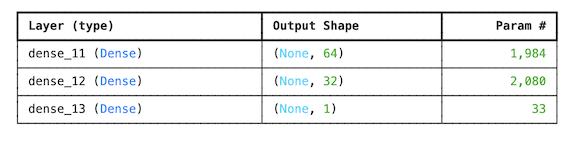

Then answer the graded questions.

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

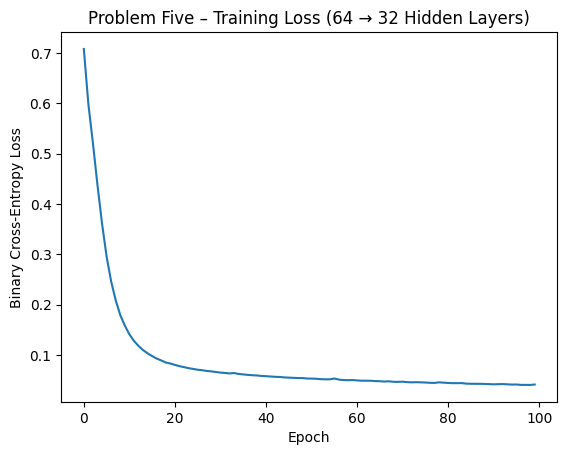

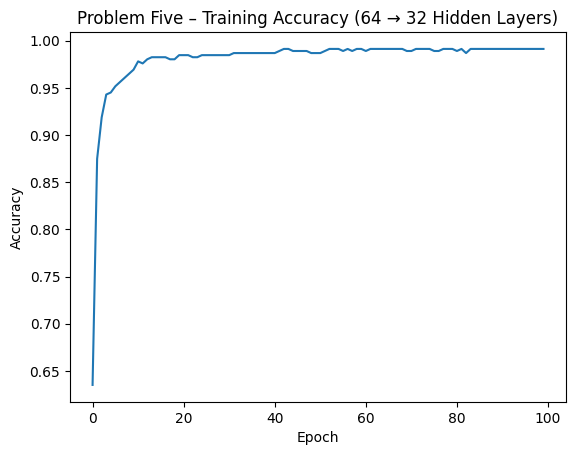

In [46]:
# Your code here, add additional cells if you wish
# ------------------------------------------------------------
# Problem Five: Training
# Two hidden layers: 64 -> 32 neurons (sigmoid activations)
# ------------------------------------------------------------
# This model increases depth rather than width.
# The goal is to compare deep vs wide architectures
# under identical training conditions.
# ------------------------------------------------------------

n_epochs = 100

# Step 1: Define the model
model_p5 = keras.Sequential(
    [
        keras.layers.Input(shape=(X_train_scaled.shape[1],)),
        keras.layers.Dense(64, activation="sigmoid"),
        keras.layers.Dense(32, activation="sigmoid"),
        keras.layers.Dense(1, activation="sigmoid")
    ]
)

model_p5.summary()

# Step 2: Compile the model
# Same optimizer and loss for fair comparison
model_p5.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Step 3: Train the model with class weighting
history_p5 = model_p5.fit(
    X_train_scaled,
    y_train,
    epochs=n_epochs,
    batch_size=32,
    class_weight=class_weights,
    verbose=0
)

# Step 4: Visualize training curves
import pandas as pd
import matplotlib.pyplot as plt

history_p5_df = pd.DataFrame(history_p5.history)

plt.figure()
plt.plot(history_p5_df["loss"])
plt.title("Problem Five – Training Loss (64 → 32 Hidden Layers)")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.show()

plt.figure()
plt.plot(history_p5_df["accuracy"])
plt.title("Problem Five – Training Accuracy (64 → 32 Hidden Layers)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()


In [47]:
# Set a5a to the final training accuracy
# Use the appropriate variable or expression; do not insert a constant from inspection of the results

a5a = history_p5.history["accuracy"][-1]

In [48]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5a = {a5a:.4f}') 

a5a = 0.9912


In [49]:
# Set a5b to the final testing accuracy
# Use the appropriate variable; do not insert a constant from inspection of the results

# ------------------------------------------------------------
# Problem Five: Testing
# Evaluate generalization on unseen test data
# ------------------------------------------------------------

test_loss_p5, test_accuracy_p5 = model_p5.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print(f"Problem Five Test Loss: {test_loss_p5:.4f}")
print(f"Problem Five Test Accuracy: {test_accuracy_p5:.4f}")

a5b = test_accuracy_p5

Problem Five Test Loss: 0.1122
Problem Five Test Accuracy: 0.9474


In [50]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5b = {a5b:.4f}') 

a5b = 0.9474


## Reflection Questions:

You won't be graded on these, and you don't need to write anything, but here are some things to think about after completing the experiments. 

1. After the baseline, we tried wider and wider models, and then a deeper model. Which idea worked better in terms of training accuracy (at least for this data split)? What model would you try next to test this hypothesis?

2. What effect did these experiments have on the testing accuracy?  Can you suggest an explanation for this? Rather than me giving you ideas, have a conversation with `ChatGPT` in which you describe your experiments, and the dataset, and explore with it why the testing results turned out this way.

3. What do you think would happen if you tried running the same experiments with a different random seed (and hence a different split in a fairly small dataset)?  